In [3]:
# Cell 1 (fixed) — Load master panel dari Blob Storage
from azure.storage.blob import BlobServiceClient
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

STORAGE_ACCOUNT = "stfinalertai"
STORAGE_KEY = "YOUR_AZURE_STORAGE_KEY"
CONTAINER = "finalert-data"

blob_service = BlobServiceClient(
    account_url=f"https://{STORAGE_ACCOUNT}.blob.core.windows.net",
    credential=STORAGE_KEY
)
container_client = blob_service.get_container_client(CONTAINER)

# Load master panel
blob = container_client.get_blob_client("cleaned/master_panel.parquet")
data = blob.download_blob().readall()
df = pd.read_parquet(io.BytesIO(data))

# Fix periode — buang yang invalid (202-03-01)
df['periode'] = pd.to_datetime(df['periode'], errors='coerce')
before = len(df)
df = df.dropna(subset=['periode'])
df = df[df['periode'].dt.year >= 2021]
after = len(df)

print(f"✅ Master panel loaded: {df.shape}")
print(f"   Dropped {before - after} baris invalid periode")
print(f"   Periode: {df['periode'].min()} s/d {df['periode'].max()}")
print(f"   Provinsi: {df['provinsi'].nunique()}")

✅ Master panel loaded: (2040, 20)
   Dropped 38 baris invalid periode
   Periode: 2021-01-01 00:00:00 s/d 2025-12-01 00:00:00
   Provinsi: 38


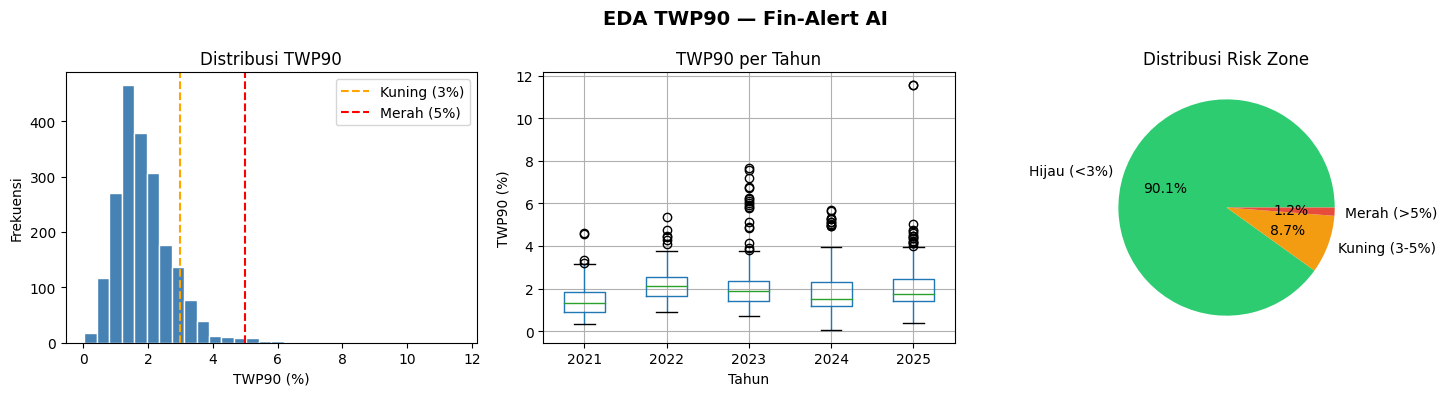

✅ Plot distribusi TWP90 selesai!


In [4]:
# Cell 2 — EDA: Distribusi TWP90
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(df['twp90_pct'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(3, color='orange', linestyle='--', label='Kuning (3%)')
axes[0].axvline(5, color='red', linestyle='--', label='Merah (5%)')
axes[0].set_title('Distribusi TWP90')
axes[0].set_xlabel('TWP90 (%)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Boxplot per tahun
df['tahun'] = df['periode'].dt.year
df.boxplot(column='twp90_pct', by='tahun', ax=axes[1])
axes[1].set_title('TWP90 per Tahun')
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('TWP90 (%)')
plt.sca(axes[1])
plt.title('TWP90 per Tahun')

# Risk zone pie chart
df['risk_zone'] = pd.cut(df['twp90_pct'],
    bins=[0, 3, 5, 100],
    labels=['Hijau (<3%)', 'Kuning (3-5%)', 'Merah (>5%)'])
risk_counts = df['risk_zone'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[2].pie(risk_counts, labels=risk_counts.index,
            autopct='%1.1f%%', colors=colors)
axes[2].set_title('Distribusi Risk Zone')

plt.suptitle('EDA TWP90 — Fin-Alert AI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_twp90_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot distribusi TWP90 selesai!")

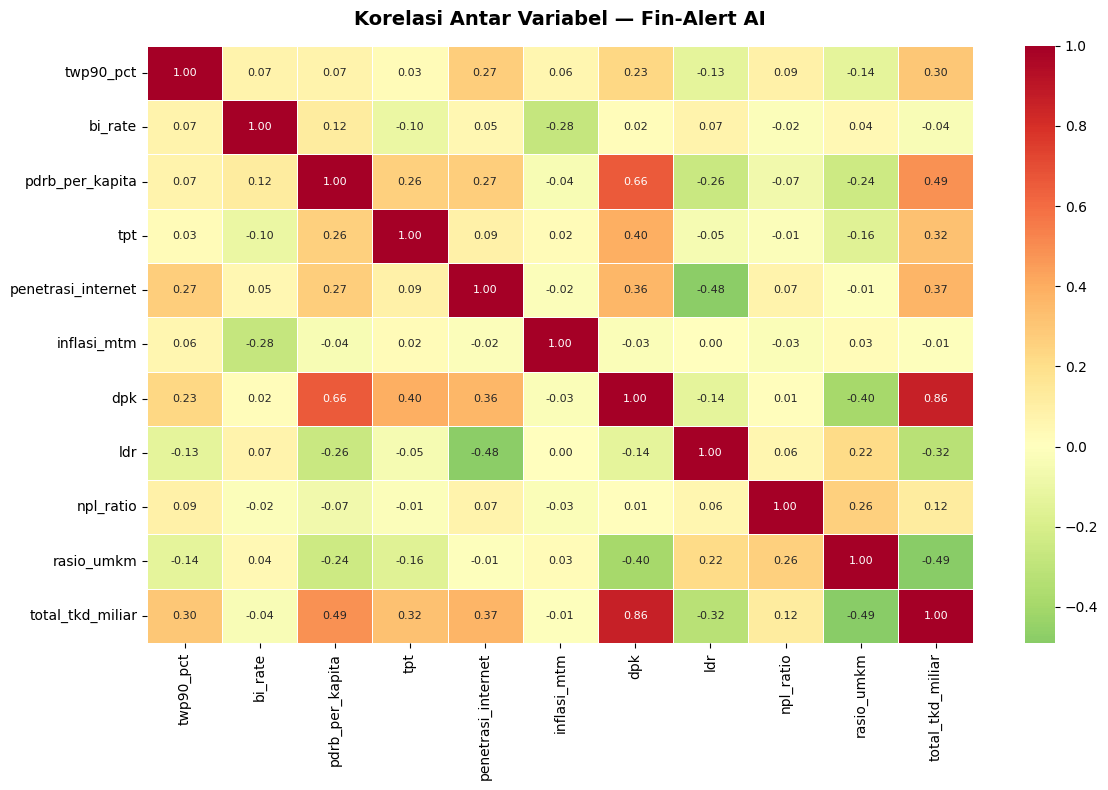


📊 Top korelasi dengan TWP90:
   ↑ total_tkd_miliar: 0.297
   ↑ penetrasi_internet: 0.270
   ↑ dpk: 0.230
   ↓ rasio_umkm: -0.139
   ↓ ldr: -0.132
   ↑ npl_ratio: 0.088
   ↑ bi_rate: 0.074
   ↑ pdrb_per_kapita: 0.071
   ↑ inflasi_mtm: 0.062
   ↑ tpt: 0.030


In [5]:
# Cell 3 — Heatmap Korelasi
numeric_cols = ['twp90_pct','bi_rate','pdrb_per_kapita','tpt',
                'penetrasi_internet','inflasi_mtm','dpk','ldr',
                'npl_ratio','rasio_umkm','total_tkd_miliar']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
mask = corr.isnull()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, mask=mask,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Korelasi Antar Variabel — Fin-Alert AI', 
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top korelasi dengan TWP90
print("\n📊 Top korelasi dengan TWP90:")
corr_twp90 = corr['twp90_pct'].drop('twp90_pct').sort_values(key=abs, ascending=False)
for var, val in corr_twp90.items():
    arah = "↑" if val > 0 else "↓"
    print(f"   {arah} {var}: {val:.3f}")

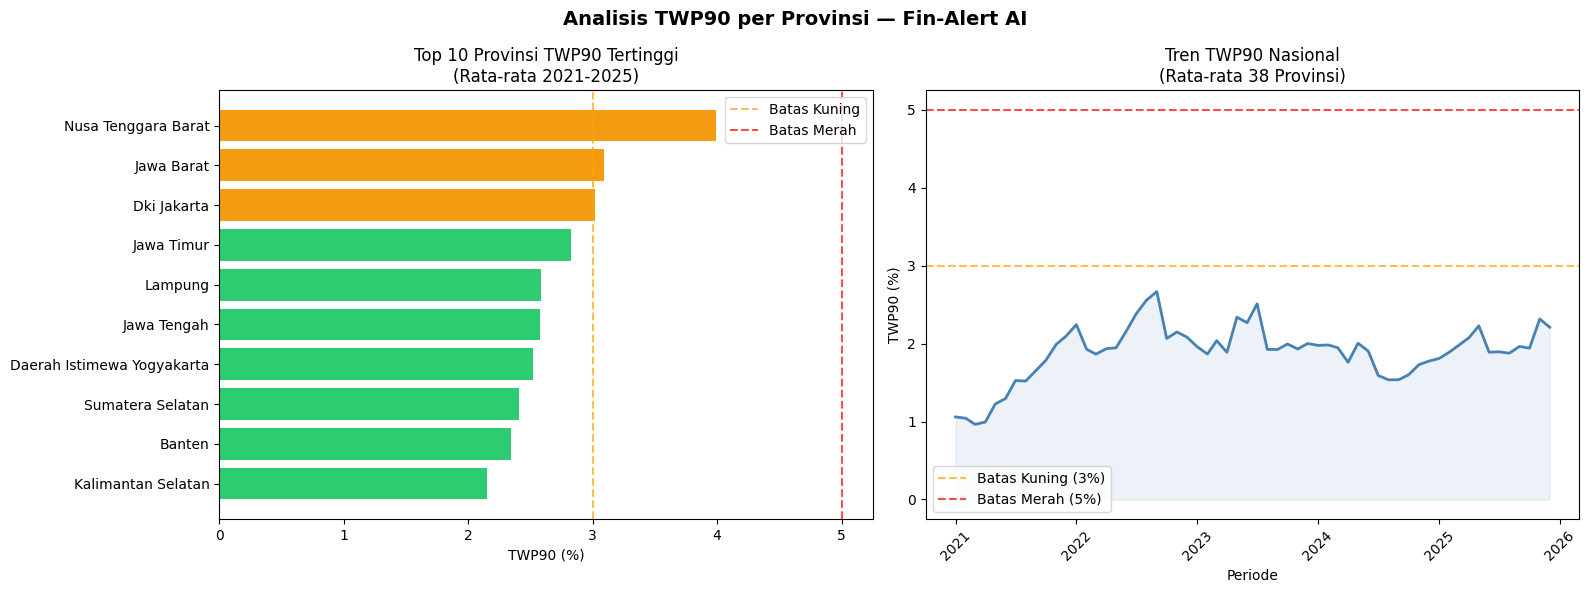


📊 Top 10 Provinsi TWP90 Tertinggi:
   🟡 Nusa Tenggara Barat: 3.99%
   🟡 Jawa Barat: 3.09%
   🟡 Dki Jakarta: 3.02%
   🟢 Jawa Timur: 2.82%
   🟢 Lampung: 2.59%
   🟢 Jawa Tengah: 2.58%
   🟢 Daerah Istimewa Yogyakarta: 2.52%
   🟢 Sumatera Selatan: 2.41%
   🟢 Banten: 2.35%
   🟢 Kalimantan Selatan: 2.15%


In [6]:
# Cell 4 — Top 10 Provinsi TWP90 Tertinggi (rata-rata)
prov_avg = df.groupby('provinsi')['twp90_pct'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart top 10
top10 = prov_avg.head(10)
colors = ['#e74c3c' if v > 5 else '#f39c12' if v > 3 else '#2ecc71' for v in top10]
axes[0].barh(top10.index[::-1], top10.values[::-1], color=colors[::-1])
axes[0].axvline(3, color='orange', linestyle='--', alpha=0.7, label='Batas Kuning')
axes[0].axvline(5, color='red', linestyle='--', alpha=0.7, label='Batas Merah')
axes[0].set_title('Top 10 Provinsi TWP90 Tertinggi\n(Rata-rata 2021-2025)')
axes[0].set_xlabel('TWP90 (%)')
axes[0].legend()

# Tren TWP90 nasional per bulan
df_nasional = df.groupby('periode')['twp90_pct'].mean().reset_index()
axes[1].plot(df_nasional['periode'], df_nasional['twp90_pct'], 
             color='steelblue', linewidth=2)
axes[1].axhline(3, color='orange', linestyle='--', alpha=0.7, label='Batas Kuning (3%)')
axes[1].axhline(5, color='red', linestyle='--', alpha=0.7, label='Batas Merah (5%)')
axes[1].fill_between(df_nasional['periode'], df_nasional['twp90_pct'], 
                      alpha=0.1, color='steelblue')
axes[1].set_title('Tren TWP90 Nasional\n(Rata-rata 38 Provinsi)')
axes[1].set_xlabel('Periode')
axes[1].set_ylabel('TWP90 (%)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Analisis TWP90 per Provinsi — Fin-Alert AI', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_twp90_provinsi.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Top 10 Provinsi TWP90 Tertinggi:")
for prov, val in prov_avg.head(10).items():
    zona = "🔴" if val > 5 else "🟡" if val > 3 else "🟢"
    print(f"   {zona} {prov}: {val:.2f}%")

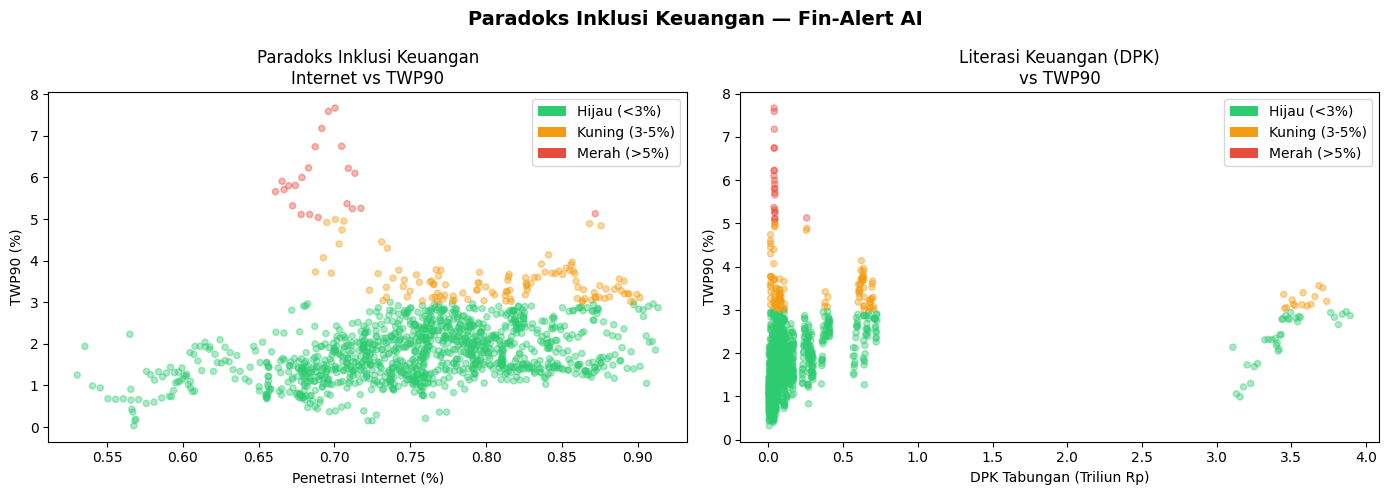

✅ Plot paradoks inklusi selesai!


In [7]:
# Cell 5 — Paradoks Inklusi: Internet vs TWP90
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: penetrasi internet vs TWP90
colors_zone = df['risk_zone'].map({
    'Hijau (<3%)': '#2ecc71',
    'Kuning (3-5%)': '#f39c12', 
    'Merah (>5%)': '#e74c3c'
})
axes[0].scatter(df['penetrasi_internet'], df['twp90_pct'],
                c=colors_zone, alpha=0.4, s=20)
axes[0].set_xlabel('Penetrasi Internet (%)')
axes[0].set_ylabel('TWP90 (%)')
axes[0].set_title('Paradoks Inklusi Keuangan\nInternet vs TWP90')
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Hijau (<3%)'),
    Patch(facecolor='#f39c12', label='Kuning (3-5%)'),
    Patch(facecolor='#e74c3c', label='Merah (>5%)')
]
axes[0].legend(handles=legend_elements)

# Scatter: DPK (literasi) vs TWP90
axes[1].scatter(df['dpk']/1e6, df['twp90_pct'],
                c=colors_zone, alpha=0.4, s=20)
axes[1].set_xlabel('DPK Tabungan (Triliun Rp)')
axes[1].set_ylabel('TWP90 (%)')
axes[1].set_title('Literasi Keuangan (DPK)\nvs TWP90')
axes[1].legend(handles=legend_elements)

plt.suptitle('Paradoks Inklusi Keuangan — Fin-Alert AI',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_paradoks_inklusi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot paradoks inklusi selesai!")

In [8]:
# Cell 6 — Upload semua plot EDA ke Blob outputs/
import os

plots = ['eda_twp90_distribusi.png', 'eda_korelasi.png', 
         'eda_twp90_provinsi.png', 'eda_paradoks_inklusi.png']

for plot in plots:
    if os.path.exists(plot):
        with open(plot, 'rb') as f:
            blob_client = container_client.get_blob_client(f"outputs/{plot}")
            blob_client.upload_blob(f, overwrite=True)
        print(f"✅ {plot} diupload!")

print("\n✅ Semua plot EDA tersimpan di Blob outputs/")

✅ eda_twp90_distribusi.png diupload!
✅ eda_korelasi.png diupload!
✅ eda_twp90_provinsi.png diupload!
✅ eda_paradoks_inklusi.png diupload!

✅ Semua plot EDA tersimpan di Blob outputs/
